## Orchestrator / Sub-agent 패턴 설계

멀티 에이전트 시스템을 구성하는 방법은 여러 가지지만, 그중 가장 널리 쓰이는 구조가 **Orchestrator(오케스트레이터) - Sub-agent(하위 에이전트)** 패턴이다.

- **Orchestrator**: 사용자 요청을 받아 이를 수행 가능한 단위 작업(sub-task)으로 분해하고, 각 작업을 처리할 적절한 sub-agent를 선정해 실행 순서를 계획한다. 직접 최종 답을 만들지 않고 "무엇을, 누가, 어떤 순서로" 할지만 결정한다.
- **Sub-agent**: 각자 좁고 명확한 역할(리서치, 계산, 문서 작성 등)만 담당하는 전문 실행 단위다. LLM일 수도 있고, 결정적인 도구(함수)일 수도 있다.
- **Synthesizer**: 모든 sub-agent의 결과를 모아 사용자에게 돌려줄 최종 응답을 합성한다.

단일 에이전트에게 모든 역할(계획 + 검색 + 계산 + 글쓰기)을 맡기면 프롬프트가 비대해지고 실패 지점을 추적하기 어렵다. Orchestrator/Sub-agent 패턴은 **관심사를 분리**해서 각 단계를 독립적으로 테스트·교체할 수 있게 하고, orchestrator가 매 요청마다 필요한 sub-agent만 동적으로 선택하게 만든다.

이 노트북에서는 LangGraph로 다음 구조를 구현한다.

```
        ┌──────────────┐
        │ orchestrator │  (LLM: 요청을 sub-task 목록으로 분해)
        └──────┬───────┘
               │  (다음 sub-task의 agent에 따라 라우팅)
     ┌─────────┼─────────┐
     ▼         ▼         ▼
  research  calculator  writer   (전문 sub-agent들, 서로 재귀적으로 라우팅)
     └─────────┴─────────┘
               ▼
        ┌──────────────┐
        │ synthesizer  │  (모든 결과를 모아 최종 답변 생성)
        └──────────────┘
```

예시 시나리오: "스타트업 A, B, C의 투자 유치 금액 합계를 구하고, 이를 바탕으로 투자자에게 보낼 요약 이메일 한 문단을 작성해줘" 라는 요청을 orchestrator가 **리서치 → 계산 → 작성** 3단계로 쪼개고, 각 단계를 전담 sub-agent에게 위임한다.

In [1]:
import os
from dotenv import load_dotenv

# .env 파일에서 API 키 불러오기
load_dotenv("C:/env/.env")

True

### [0] 사전 준비: LLM, 상태(State) 정의

In [2]:
from typing import Dict, List, Literal, TypedDict

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [3]:
class AgentState(TypedDict):
    request: str                  # 사용자 원본 요청
    plan: List[Dict[str, str]]    # orchestrator가 수립한 전체 계획 (기록용)
    pending: List[Dict[str, str]] # 아직 실행하지 않은 sub-task 큐
    completed: List[Dict[str, str]]  # 실행이 끝난 sub-task와 그 결과
    final_answer: str             # synthesizer가 만든 최종 답변

### [1] Orchestrator: 요청을 sub-task로 분해

orchestrator는 `with_structured_output`으로 사용자 요청을 **실행 순서가 정해진 sub-task 목록**으로 변환한다. 각 sub-task는 담당할 agent 이름(`research` / `calculator` / `writer`)과 해당 agent에게 전달할 구체적 지시사항으로 구성된다.

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field


class SubTask(BaseModel):
    agent: Literal["research", "calculator", "writer"] = Field(
        description="이 하위 작업을 수행할 sub-agent"
    )
    instruction: str = Field(description="해당 sub-agent에게 전달할 구체적인 지시사항")


class Plan(BaseModel):
    subtasks: List[SubTask] = Field(description="실행 순서대로 정렬된 하위 작업 목록")


planner_llm = llm.with_structured_output(Plan)

orchestrator_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "너는 멀티 에이전트 시스템의 orchestrator다. 사용자 요청을 분석해 아래 sub-agent들만 사용해 "
            "실행 순서가 있는 계획을 세워라. 직접 답을 만들지 말고 계획만 세운다.\n\n"
            "- research: 스타트업의 투자 유치 관련 사실 정보를 조회한다.\n"
            "- calculator: 앞선 research 결과에 등장한 숫자를 계산(합산 등)한다.\n"
            "- writer: 지금까지의 결과를 바탕으로 자연스러운 글을 작성한다.\n\n"
            "필요한 sub-agent만, 필요한 순서로만 포함시켜라.",
        ),
        ("human", "{request}"),
    ]
)


def orchestrator_node(state: AgentState) -> dict:
    plan = planner_llm.invoke(orchestrator_prompt.format_messages(request=state["request"]))
    subtasks = [st.model_dump() for st in plan.subtasks]

    print(f"[Orchestrator] 계획 수립 완료: {len(subtasks)}개 하위 작업")
    for i, st in enumerate(subtasks, 1):
        print(f"  {i}. ({st['agent']}) {st['instruction']}")

    return {"plan": subtasks, "pending": list(subtasks), "completed": []}

### [2] Sub-agent 구현

각 sub-agent는 `state["pending"]`의 맨 앞 작업을 꺼내 처리하고, 그 결과를 `state["completed"]`에 쌓은 뒤 자신이 처리한 작업을 큐에서 제거한다.

- `research`: 결정적인 지식 조회(모의 DB 검색) — LLM 호출 없이 동작하는 tool 형태의 sub-agent
- `calculator`: 이전 결과에서 숫자를 뽑아 계산하는 결정적인 tool 형태의 sub-agent
- `writer`: LLM을 호출해 지금까지의 결과를 자연스러운 글로 다듬는 sub-agent

실제 시스템에서도 모든 sub-agent가 LLM일 필요는 없다. 결정적으로 처리 가능한 작업은 tool로 두는 편이 더 빠르고 안정적이다.

In [5]:
import re

# research sub-agent가 조회할 모의 지식베이스
FUNDING_FACTS = {
    "A": "스타트업 A는 시리즈 B 라운드에서 120억원을 유치했다.",
    "B": "스타트업 B는 시드 라운드에서 35억원을 유치했다.",
    "C": "스타트업 C는 시리즈 A 라운드에서 68억원을 유치했다.",
}


def research_node(state: AgentState) -> dict:
    task = state["pending"][0]
    instruction = task["instruction"]

    hits = [fact for name, fact in FUNDING_FACTS.items() if name in instruction]
    if not hits:
        hits = list(FUNDING_FACTS.values())
    result = " ".join(hits)

    print(f"[Research] {result}")

    return {
        "pending": state["pending"][1:],
        "completed": state["completed"] + [{"agent": "research", "instruction": instruction, "result": result}],
    }


def calculator_node(state: AgentState) -> dict:
    task = state["pending"][0]
    instruction = task["instruction"]

    # 지금까지 완료된 하위 작업 결과 중에서 "N억원" 패턴의 숫자를 모두 찾아 합산한다
    source_text = " ".join(c["result"] for c in state["completed"])
    numbers = [int(n) for n in re.findall(r"(\d+)억원", source_text)]
    total = sum(numbers)
    result = f"{' + '.join(map(str, numbers))} = {total}억원"

    print(f"[Calculator] {result}")

    return {
        "pending": state["pending"][1:],
        "completed": state["completed"] + [{"agent": "calculator", "instruction": instruction, "result": result}],
    }


writer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "너는 투자자에게 보낼 정중하고 간결한 이메일 문단을 작성하는 라이터 에이전트다. "
            "아래 참고 자료에 있는 사실만 사용하고, 새로운 정보를 지어내지 마라.",
        ),
        ("human", "지시사항: {instruction}\n\n참고 자료:\n{context}"),
    ]
)


def writer_node(state: AgentState) -> dict:
    task = state["pending"][0]
    instruction = task["instruction"]
    context = "\n".join(f"- ({c['agent']}) {c['result']}" for c in state["completed"])

    response = llm.invoke(writer_prompt.format_messages(instruction=instruction, context=context))
    result = response.content

    print(f"[Writer]\n{result}")

    return {
        "pending": state["pending"][1:],
        "completed": state["completed"] + [{"agent": "writer", "instruction": instruction, "result": result}],
    }

### [3] Synthesizer: 최종 답변 합성

모든 sub-task 처리가 끝나면 synthesizer가 결과를 종합한다. `writer`가 실행됐다면 그 결과를 최종 답변으로 삼고, 그렇지 않다면(예: 계산만 요청한 경우) 완료된 작업 결과를 그대로 나열한다.

In [6]:
def synthesizer_node(state: AgentState) -> dict:
    writer_results = [c["result"] for c in state["completed"] if c["agent"] == "writer"]

    if writer_results:
        final = writer_results[-1]
    else:
        final = "\n".join(f"- ({c['agent']}) {c['result']}" for c in state["completed"])

    print("[Synthesizer] 최종 답변 조합 완료")

    return {"final_answer": final}

### [4] 라우팅 로직과 그래프 구성

핵심은 `route_next` 하나로 모든 라우팅을 처리한다는 점이다. orchestrator를 포함해 모든 노드 실행 뒤에는 `state["pending"]`의 맨 앞 작업이 어떤 agent를 지정했는지만 보고 다음 노드를 정한다. 큐가 비었으면 synthesizer로 넘어간다. 이렇게 하면 sub-agent 수가 늘어나도 라우팅 로직 자체는 바뀌지 않는다.

In [ ]:
from langgraph.graph import END, StateGraph

SUB_AGENTS = ["research", "calculator", "writer"]


def route_next(state: AgentState) -> str:
    if not state["pending"]:
        return "synthesizer"
    return state["pending"][0]["agent"]


route_map = {agent: agent for agent in SUB_AGENTS}
route_map["synthesizer"] = "synthesizer"

graph = StateGraph(AgentState)
graph.add_node("orchestrator", orchestrator_node)
graph.add_node("research", research_node)
graph.add_node("calculator", calculator_node)
graph.add_node("writer", writer_node)
graph.add_node("synthesizer", synthesizer_node)

graph.set_entry_point("orchestrator")

# orchestrator와 모든 sub-agent는 동일한 route_next 규칙으로 다음 노드를 정한다
for node in ["orchestrator", "research", "calculator", "writer"]:
    graph.add_conditional_edges(node, route_next, route_map)

graph.add_edge("synthesizer", END)

app = graph.compile()

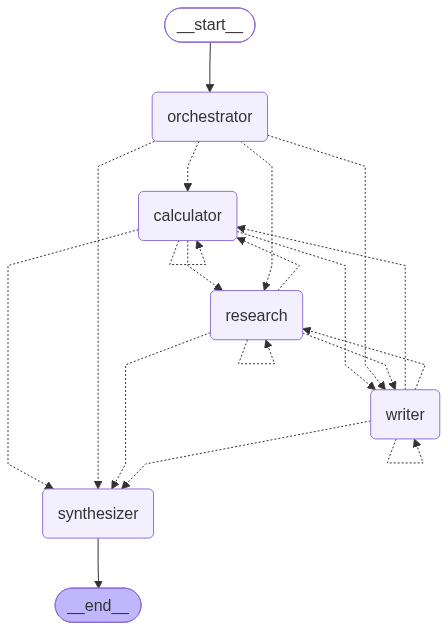

In [ ]:
# LangGraph 시각화
from IPaython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

### [5] 실행: 리서치 → 계산 → 작성 시나리오

orchestrator가 요청 하나를 세 개의 sub-task로 쪼개고, 각 sub-agent가 순서대로 실행되는 과정을 로그로 확인한다.

In [10]:
request = (
    "스타트업 A, B, C의 투자 유치 금액 합계를 구하고, "
    "이를 바탕으로 투자자에게 보낼 요약 이메일 한 문단을 작성해줘."
)

result = app.invoke({"request": request})

print("\n=== 최종 답변 ===")
print(result["final_answer"])

[Orchestrator] 계획 수립 완료: 3개 하위 작업
  1. (research) 스타트업 A, B, C의 투자 유치 금액을 조회한다.
  2. (calculator) 스타트업 A, B, C의 투자 유치 금액 합계를 계산한다.
  3. (writer) 계산된 투자 유치 금액을 바탕으로 투자자에게 보낼 요약 이메일 한 문단을 작성한다.
[Research] 스타트업 A는 시리즈 B 라운드에서 120억원을 유치했다. 스타트업 B는 시드 라운드에서 35억원을 유치했다. 스타트업 C는 시리즈 A 라운드에서 68억원을 유치했다.
[Calculator] 120 + 35 + 68 = 223억원
[Writer]
안녕하세요, [투자자 이름]님. 최근 스타트업 A가 시리즈 B 라운드에서 120억원, 스타트업 B가 시드 라운드에서 35억원, 그리고 스타트업 C가 시리즈 A 라운드에서 68억원을 유치하여 총 223억원의 투자 유치가 이루어졌습니다. 이와 같은 성과는 시장의 긍정적인 반응을 반영하고 있으며, 앞으로의 성장 가능성을 더욱 기대하게 합니다. 감사합니다.
[Synthesizer] 최종 답변 조합 완료

=== 최종 답변 ===
안녕하세요, [투자자 이름]님. 최근 스타트업 A가 시리즈 B 라운드에서 120억원, 스타트업 B가 시드 라운드에서 35억원, 그리고 스타트업 C가 시리즈 A 라운드에서 68억원을 유치하여 총 223억원의 투자 유치가 이루어졌습니다. 이와 같은 성과는 시장의 긍정적인 반응을 반영하고 있으며, 앞으로의 성장 가능성을 더욱 기대하게 합니다. 감사합니다.


### [6] 실행: sub-agent가 일부만 필요한 시나리오

orchestrator는 요청에 따라 필요한 sub-agent만 동적으로 선택한다. 아래처럼 "글쓰기" 없이 순수 계산만 요청하면 orchestrator는 `writer` 없는 계획을 세우고, synthesizer는 completed 결과를 그대로 나열해 답한다.

In [15]:
request2 = "스타트업 A와 B가 유치한 금액의 합계만 숫자로 알려줘."
# request2 = "스타트업 A는 ?"
result2 = app.invoke({"request": request2})

print("\n=== 최종 답변 ===")
print(result2["final_answer"])

[Orchestrator] 계획 수립 완료: 2개 하위 작업
  1. (research) 스타트업 A와 B가 유치한 투자 금액을 조회한다.
  2. (calculator) 스타트업 A와 B의 투자 금액을 합산한다.
[Research] 스타트업 A는 시리즈 B 라운드에서 120억원을 유치했다. 스타트업 B는 시드 라운드에서 35억원을 유치했다.
[Calculator] 120 + 35 = 155억원
[Synthesizer] 최종 답변 조합 완료

=== 최종 답변 ===
- (research) 스타트업 A는 시리즈 B 라운드에서 120억원을 유치했다. 스타트업 B는 시드 라운드에서 35억원을 유치했다.
- (calculator) 120 + 35 = 155억원


### 정리

- **Orchestrator**는 실행을 직접 하지 않고 계획(어떤 sub-agent를, 어떤 순서로)만 세운다. 이 계획을 `pending` 큐로 표현하면 라우팅 로직(`route_next`)이 sub-agent 종류와 무관하게 단순해진다.
- **Sub-agent**는 각자 좁은 역할만 맡는다. 결정적으로 처리 가능한 작업(`research`, `calculator`)은 LLM 호출 없는 tool로 구현해 속도와 안정성을 확보하고, 자연어 생성처럼 LLM이 꼭 필요한 작업(`writer`)만 LLM을 호출한다.
- **Synthesizer**는 실행된 sub-agent 구성이 매번 달라져도 `completed` 리스트만 보고 일관된 방식으로 최종 답을 조합한다.
- 이 구조는 sub-agent를 추가/교체하기 쉽다. 새 역할(예: `translator`)이 필요하면 노드 하나 추가하고 `SUB_AGENTS`와 orchestrator 프롬프트에 반영하면 된다 — 라우팅 로직은 그대로 재사용된다.